# ERS Assignment – MNIST Autoencoder

This notebook demonstrates a complete workflow for a typical **Electronic Resources Systems (ERS)** assignment that involves building, training, and evaluating a simple autoencoder on the MNIST handwritten‑digit dataset.  The steps are:
1. **Load the data** – using `torchvision.datasets.MNIST`.
2. **Define the model** – a fully‑connected (FFNN) autoencoder.
3. **Train** the model, monitoring training and validation loss.
4. **Save** the best checkpoint.
5. **Visualise** loss curves.
6. **Reconstruct** test images and compare with the originals.

All code is written in plain PyTorch and can be executed in any standard Jupyter environment.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, SubsetRandomSampler
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
import os

## Hyper‑parameters
These values are typical for a quick prototype. Feel free to adjust them for experimentation.

In [2]:
batch_size   = 128
learning_rate = 1e-3
num_epochs   = 20
valid_size   = 0.2  # fraction of training set used for validation
num_workers  = 0    # set >0 for multi‑process loading on Unix systems

## Add Gaussian Noise
This function adds Gaussian noise to the input images.


In [3]:
def add_noise(images, noise_factor=0.4):
    noisy = images + noise_factor * torch.randn_like(images)
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy


## Data loading
We split the official training set into a **training** and a **validation** subset. The test set is kept untouched for final evaluation.

In [4]:
transform = transforms.ToTensor()
train_data = datasets.MNIST(root='data', train=True, download=True, transform=transform)
test_data  = datasets.MNIST(root='data', train=False, download=True, transform=transform)

train_len = len(train_data)
indices   = list(range(train_len))
np.random.shuffle(indices)
split      = int(np.floor(valid_size * train_len))
train_idx, valid_idx = indices[split:], indices[:split]
train_sampler = SubsetRandomSampler(train_idx)
valid_sampler = SubsetRandomSampler(valid_idx)

train_loader = DataLoader(train_data, batch_size=batch_size, sampler=train_sampler, num_workers=num_workers)
valid_loader = DataLoader(train_data, batch_size=batch_size, sampler=valid_sampler, num_workers=num_workers)
test_loader  = DataLoader(test_data,  batch_size=batch_size, shuffle=False,           num_workers=num_workers)

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 486kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.44MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.82MB/s]


## Model definition – Fully‑Connected Autoencoder
The encoder compresses the 28×28 image (784 pixels) to a low‑dimensional latent vector. The decoder reconstructs the image from that latent code.

In [5]:
class AutoEncoder(nn.Module):
    def __init__(self, latent_dim: int = 32):
        super(AutoEncoder, self).__init__()
        # Encoder – flatten → hidden → latent
        self.encoder = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(True),
            nn.Linear(128, latent_dim),
        )
        # Decoder – latent → hidden → image
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.ReLU(True),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid(),
            nn.Unflatten(1, (1, 28, 28)),
        )

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z)

## Training utilities
We use Mean‑Squared‑Error (MSE) as the reconstruction loss and Adam as the optimiser.

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = AutoEncoder().to(device)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
train_losses, val_losses = [], []

### One training epoch

In [7]:
def train_one_epoch(epoch: int):
    model.train()
    running_loss = 0.0
    for imgs, _ in train_loader:
        imgs = imgs.to(device)
        optimizer.zero_grad()
        noisy_imgs = add_noise(imgs)
        outputs = model(noisy_imgs)
        loss = criterion(outputs, imgs)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * imgs.size(0)
    epoch_loss = running_loss / len(train_idx)
    print(f'[Epoch {epoch+1}/{num_epochs}] Train loss: {epoch_loss:.6f}')
    train_losses.append(epoch_loss)
    return epoch_loss

### Validation epoch

In [8]:
def validate(epoch: int):
    model.eval()
    val_running = 0.0
    with torch.no_grad():
        for imgs, _ in valid_loader:
            imgs = imgs.to(device)
            noisy_imgs = add_noise(imgs)
            outputs = model(noisy_imgs)
            loss = criterion(outputs, imgs)
            val_running += loss.item() * imgs.size(0)
    val_loss = val_running / len(valid_idx)
    print(f'[Epoch {epoch+1}/{num_epochs}] Validation loss: {val_loss:.6f}')
    val_losses.append(val_loss)
    return val_loss

## Training loop
The loop saves the **best** model (lowest validation loss) to `F_Auto_MNIST_model.pth`.

In [9]:
best_val = float('inf')
for epoch in range(num_epochs):
    train_one_epoch(epoch)
    val = validate(epoch)
    if val < best_val:
        best_val = val
        ckpt_path = os.path.join('F_Auto_MNIST_model.pth')
        torch.save(model.state_dict(), ckpt_path)
        print(f'Saved improved model to {ckpt_path}')

[Epoch 1/20] Train loss: 0.057461
[Epoch 1/20] Validation loss: 0.037232
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 2/20] Train loss: 0.031367
[Epoch 2/20] Validation loss: 0.027544
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 3/20] Train loss: 0.025334
[Epoch 3/20] Validation loss: 0.023749
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 4/20] Train loss: 0.022576
[Epoch 4/20] Validation loss: 0.021793
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 5/20] Train loss: 0.020817
[Epoch 5/20] Validation loss: 0.020214
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 6/20] Train loss: 0.019427
[Epoch 6/20] Validation loss: 0.019156
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 7/20] Train loss: 0.018300
[Epoch 7/20] Validation loss: 0.017851
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 8/20] Train loss: 0.017382
[Epoch 8/20] Validation loss: 0.017083
Saved improved model to F_Auto_MNIST_model.pth
[Epoch 9/20] Train loss: 0.016754
[Epoch

## Plotting loss curves

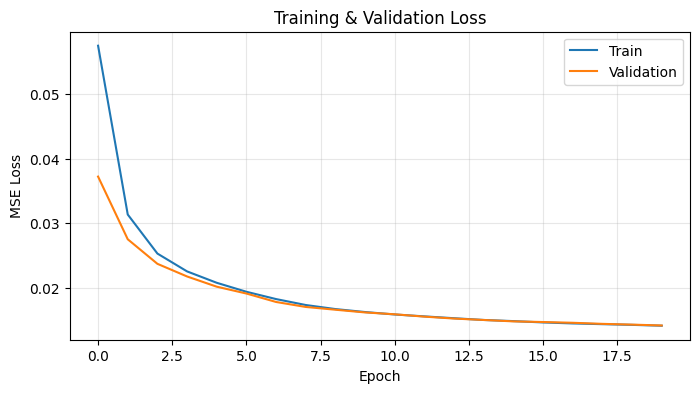

In [10]:
plt.figure(figsize=(8,4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Validation')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Training & Validation Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Visualising reconstructions on the test set

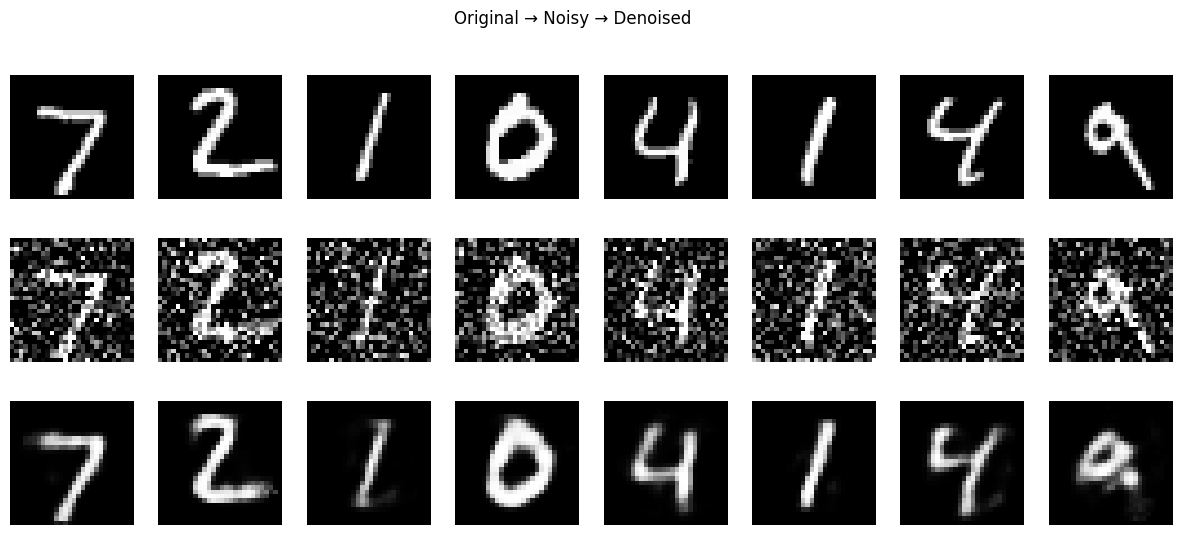

In [11]:
model.eval()
with torch.no_grad():
    test_imgs, _ = next(iter(test_loader))
    test_imgs = test_imgs.to(device)
    noisy_imgs = add_noise(test_imgs)
    recon = model(noisy_imgs)

    test_imgs = test_imgs.cpu()
    noisy_imgs = noisy_imgs.cpu()
    recon = recon.cpu()

    n = 8
    plt.figure(figsize=(15,6))

    for i in range(n):
        ax = plt.subplot(3,n,i+1)
        plt.imshow(test_imgs[i][0], cmap='gray')
        ax.axis('off')

        ax = plt.subplot(3,n,i+1+n)
        plt.imshow(noisy_imgs[i][0], cmap='gray')
        ax.axis('off')

        ax = plt.subplot(3,n,i+1+2*n)
        plt.imshow(recon[i][0], cmap='gray')
        ax.axis('off')

    plt.suptitle("Original → Noisy → Denoised")
    plt.show()
